In [183]:
import numpy as np
import matplotlib.pyplot as plt
import time
from dataclasses import dataclass

np.random.seed(42)

@dataclass
class Params:
    S0: float = 100.0
    K: float = 100.0
    T: float = 1.0
    r: float = 0.05
    sigma: float = 0.5
    N: int = 300    # number of exercise dates
    M: int = 1 # number of processes (1 = standard, >1 = Asian-style)
    L: int =  3  # exercise rights
    delta: int = 0    # refractory period between exercises (0 = next step allowed)
    
    @property
    def dt(self): return self.T / self.N
    
    @property
    def df(self): return np.exp(-self.r * self.dt)

params = Params()
print(f"American Put: S0={params.S0}, K={params.K}, T={params.T}, r={params.r}, σ={params.sigma}, N={params.N}, M={params.M}, L={params.L}, delta={params.delta}")
print(f"dt={params.dt:.4f}, discount_factor={params.df:.6f}")

American Put: S0=100.0, K=100.0, T=1.0, r=0.05, σ=0.5, N=300, M=1, L=3, delta=0
dt=0.0033, discount_factor=0.999833


In [184]:
def generate_paths(params, n_paths, seed=None, randomize_S0=True):
    """
    GBM paths. If randomize_S0 is True, starting prices are drawn uniformly 
    to force the agents to learn a global policy across the whole state space.
    """
    if seed is not None:
        np.random.seed(seed)
    dt = params.dt
    Z = np.random.standard_normal((n_paths, params.N, params.M))
    drift = (params.r - 0.5 * params.sigma**2) * dt
    diffusion = params.sigma * np.sqrt(dt) * Z
    log_returns = np.cumsum(drift + diffusion, axis=1)
    
    paths = np.zeros((n_paths, params.N + 1, params.M))
    
    if randomize_S0:
        # Scatter starting prices between 40% and 160% of Strike
        S0_rand = np.random.uniform(params.K * 0.4, params.K * 1.6, (n_paths, params.M))
        paths[:, 0, :] = S0_rand
        # Expand S0 to multiply across the time dimension properly
        paths[:, 1:, :] = S0_rand[:, np.newaxis, :] * np.exp(log_returns)
    else:
        paths[:, 0, :] = params.S0
        paths[:, 1:, :] = params.S0 * np.exp(log_returns)
        
    return paths

# Generate train / test split
train_paths = generate_paths(params, 50, seed=42)
test_paths  = generate_paths(params, 100, seed=997)
print(f"Train: {train_paths.shape}, Test: {test_paths.shape}")

Train: (50, 301, 1), Test: (100, 301, 1)


In [185]:
# ── Modular payoff ──
def payoff_put(prices, K):
    """Put payoff on mean price across processes.
    prices: (..., M) → returns (...)
    M=1: standard put. M>1: Asian-style put on mean.
    """
    avg = prices.mean(axis=-1)  # mean across M processes
    return np.maximum(K - avg, 0)

# def payoff_call(prices, K):
#     """Call payoff on mean price across processes."""
#     avg = prices.mean(axis=-1)
#     return np.maximum(avg - K, 0)

def discounted_payoff(paths_t, t, params):
    """Discounted payoff at time step t. paths_t shape: (n_paths, M) or (M,)"""
    return payoff_put(paths_t, params.K) * params.df**t

# ── Basis functions ──
def poly_basis(prices, K, degree=3):
    """Polynomial basis on each process, then flatten.
    prices: (n, M) → basis: (n, M*degree + 1)
    """
    s = prices / K  # (n, M)
    features = [np.ones(len(s))]  # intercept
    for d in range(1, degree + 1):
        for m in range(s.shape[1]):
            features.append(s[:, m]**d)
    return np.column_stack(features)

# ── Pointwise V query ──
def query_V(models, prices_1d, l, t, params, degree=3):
    """Return V(l, t) for a SINGLE state (prices_1d has shape (M,)).
    Uses the already-trained regressor models[(l, t)].
    
    - l == 0 → 0
    - t > N  → 0  (past maturity)
    - t == N → terminal_value(l, prices)
    - t < N, model exists → max(exercise_val, cont_est)
    """
    if l == 0 or t > params.N:
        return 0.0
    p = payoff_put(prices_1d.reshape(1, -1), params.K).item()
    if t == params.N:
        # At maturity: exercise 1 right; if delta allows and l > 1,
        # remaining rights are wasted (can't exercise past N)
        return p
    # Look up continuation estimate from regressor
    key = (l, t)
    if key in models:
        x = poly_basis(prices_1d.reshape(1, -1), params.K, degree)[0]
        cont_est = float(x @ models[key])
    else:
        cont_est = 0.0  # no model → assume 0 continuation
    return max(p, cont_est)

def query_V_batch(models, prices, l, t, params, degree=3):
    """Vectorized V query. prices_2d: (n, M). Returns (n,) array."""
    prices_2d = prices[:,t]
    n = len(prices_2d)
    if l == 0 or t > params.N:
        return np.zeros(n)
    p = payoff_put(prices_2d, params.K)  # (n,)
    if t == params.N:
        return p
    time_left = params.N - t + 1
    if l > time_left // (params.delta + 1):
        # sum of payoff for all the remaining time steps
        for future_t in range(t, params.N + 1):
            p += payoff_put(prices[:, future_t], params.K) * params.df**(future_t - t)
        return p

    key = (l, t)
    if key in models:
        X = poly_basis(prices_2d, params.K, degree)
        cont_est = X @ models[key]
    else:
        cont_est = np.zeros(n)
    return np.maximum(p, cont_est)

print(f"Payoff test (M={params.M}): put on S=95 → {payoff_put(np.array([[95.0]]), params.K).item():.2f}")
print(f"Basis shape for 5 samples, M={params.M}: {poly_basis(np.ones((5, params.M))*100, params.K).shape}")
print(f"query_V with empty models: {query_V({}, np.array([95.0]*params.M), 1, 10, params):.2f}")

Payoff test (M=1): put on S=95 → 5.00
Basis shape for 5 samples, M=1: (5, 4)
query_V with empty models: 5.00


In [186]:
def train_lsm(paths, params, degree=3):
    """
    Standard LSM with multiple stopping rights.
    
    Bellman: V(l,t) = max( payoff(t) + df^(t_resume-t) · V(l-1, t_resume), df · V(l, t+1) )
    where t_resume = min(t + delta + 1, N).  (delta=0 → next step)
    
    V(l-1, t_resume) is queried via regressors already trained for layer l-1.
    Regression target = realized continuation = df · V(l, t+1).
    """
    N, df, K, L, delta = params.N, params.df, params.K, params.L, params.delta
    n_paths = len(paths)
    payoffs = np.array([payoff_put(paths[:, t], K) for t in range(N + 1)]).T  # (n_paths, N+1)
    
    models = {}  # keyed by (l, t)
    
    for l in range(1, L + 1):
        # Terminal: V(l, N) = payoff(N). Only 1 right can be used at maturity.
        V = payoffs[:, N].copy()    # (n_paths,)
        
        for t in range(N - 1, 0, -1):
            # After exercising at t, next exercise allowed at t_resume
            t_resume = min(t + delta + 1, N)  # delta=0 → next step
            residual = query_V_batch(models, paths, l - 1, t_resume, params, degree)
            exercise_val = payoffs[:, t] + (df ** (t_resume - t)) * residual
            
            # Continuation value at t: df · V(l, t+1) (realized from future)
            cont_val = df * V  # V currently holds value at t+1 in time-(t+1) $
            
            p_t = payoffs[:, t]
            itm = p_t > 0
            
            if itm.sum() < degree * params.M + 5:
                V = cont_val
                continue
            
            X = poly_basis(paths[itm, t], K, degree)
            Y = cont_val[itm]  # regression target = realized continuation
            
            coeffs = np.linalg.lstsq(X, Y, rcond=None)[0]
            models[(l, t)] = coeffs
            cont_est = X @ coeffs
            
            exercise = exercise_val[itm] > cont_est
            V_new = cont_val.copy()
            V_new[itm] = np.where(exercise, exercise_val[itm], cont_val[itm])
            V = V_new
    
    return models

print("Standard LSM (multi-stop) defined.")

Standard LSM (multi-stop) defined.


In [187]:
def train_td_lsm(paths, params, degree=3):
    """
    TD-LSM (Temporal Difference LSM) with multiple stopping rights.
    
    Key difference from standard LSM: regression target is the ONE-STEP
    bootstrap estimate df · V̂(l, t+1), where V̂(l, t+1) is constructed
    from the regressor already trained at t+1.
    
    The regression target at t is:  Y = df · V̂(l, t+1).
    After fitting, V̂(l, t) uses the regressor's OWN prediction (cont_est),
    NOT the raw per-path target — that's the TD idea.
    
    Crucially, V̂(l, t) is updated for ALL paths using the regressor,
    not just ITM paths, to avoid bias compounding through the raw targets.
    """
    N, df, K, L, delta = params.N, params.df, params.K, params.L, params.delta
    n_paths = len(paths)
    payoffs = np.array([payoff_put(paths[:, t], K) for t in range(N + 1)]).T
    
    models = {}
    
    for l in range(1, L + 1):
        # V_hat[i] = V̂(l, t+1) in time-(t+1) dollars.
        # At terminal: V̂(l, N) = payoff(N)
        V_hat = payoffs[:, N].copy()
        
        for t in range(N - 1, 0, -1):
            t_resume = min(t + delta + 1, N)  # delta=0 → next step
            residual = query_V_batch(models, paths, l - 1, t_resume, params, degree)
            exercise_val = payoffs[:, t] + (df ** (t_resume - t)) * residual
            
            # TD target = df · V̂(l, t+1)  (in time-t dollars)
            td_target = df * V_hat
            
            p_t = payoffs[:, t]
            itm = p_t > 0
            
            if itm.sum() < degree * params.M + 5:
                # No regression possible — V̂(l, t) = max(exercise_val, td_target)
                V_hat = np.maximum(exercise_val, td_target)
                continue
            
            X_itm = poly_basis(paths[itm, t], K, degree)
            Y = td_target[itm]  # regression target = df · V̂(l, t+1)
            
            coeffs = np.linalg.lstsq(X_itm, Y, rcond=None)[0]
            models[(l, t)] = coeffs
            
            # Compute continuation estimate for ALL paths using the regressor
            X_all = poly_basis(paths[:, t], K, degree)
            cont_est_all = X_all @ coeffs  # Ĉ(l, t) for all paths
            
            # V̂(l, t) = max(exercise_val, cont_est) for ITM paths
            # V̂(l, t) = cont_est for OTM paths (can't exercise, but still has value)
            V_hat_new = td_target.copy()  # default to td_target for all paths
            V_hat_new[itm] = np.maximum(exercise_val[itm], cont_est_all[itm])
    
            V_hat = V_hat_new
    
    return models

print("TD-LSM (multi-stop) defined.")

TD-LSM (multi-stop) defined.


In [188]:
def evaluate_policy(models, paths, params, degree=3):
    """
    Evaluate a trained LSM / TD-LSM policy on test paths.
    Handles multiple exercise rights (L) and refractory period (delta).
    
    Returns: mean discounted payoff, per-path rewards array.
    """
    N, df, K, L, delta = params.N, params.df, params.K, params.L, params.delta
    n_paths = len(paths)
    payoffs_all = np.array([payoff_put(paths[:, t], K) for t in range(N + 1)]).T
    
    rewards = np.zeros(n_paths)
    
    for i in range(n_paths):
        rights_left = L
        t = 1  # start at first exercise date
        total_reward = 0.0
        
        while t <= N and rights_left > 0:
            p_t = payoffs_all[i, t]
            
            if t == N:
                # At maturity, exercise if ITM
                if p_t > 0:
                    total_reward += p_t * (df ** t)
                    rights_left -= 1
                break
            
            if p_t <= 0:
                # OTM — can't exercise, move on
                t += 1
                continue
            
            # Query regressor for continuation value
            key = (rights_left, t)
            if key in models:
                x = poly_basis(paths[i, t].reshape(1, -1), K, degree)[0]
                cont_est = float(x @ models[key])
            else:
                cont_est = 0.0
            
            # Exercise value: payoff now + discounted future value of remaining rights
            t_resume = min(t + delta + 1, N)
            future_val = query_V(models, paths[i, t_resume], rights_left - 1, t_resume, params, degree)
            ex_val = p_t + (df ** (t_resume - t)) * future_val
            
            if ex_val > cont_est:
                # Exercise
                total_reward += p_t * (df ** t)
                rights_left -= 1
                t = t_resume  # jump past refractory period
            else:
                t += 1
        
        rewards[i] = total_reward
    
    return rewards.mean(), rewards

print("Evaluation function defined.")

Evaluation function defined.


In [189]:
# ═══════════════════════════════════════════════════════════════════════════════
# DQN Implementation (PyTorch)
# ═══════════════════════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class DQN(nn.Module):
    def __init__(self, state_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)  # 2 actions: hold or exercise
        )
    
    def forward(self, x):
        return self.net(x)


def make_state(prices, t, rights_left, params):
    """Create normalized state vector: [prices/K, t/N, rights/L]"""
    prices_norm = prices / params.K
    return np.concatenate([prices_norm, [t / params.N, rights_left / params.L]]).astype(np.float32)


def train_dqn(paths, params, hidden_dim=64, lr=1e-3, n_epochs=5, batch_size=64,
              epsilon_start=1.0, epsilon_end=0.05, target_update=100):
    """Train DQN on pre-generated paths."""
    N, K, L, delta, df = params.N, params.K, params.L, params.delta, params.df
    state_dim = params.M + 2
    
    q_net = DQN(state_dim, hidden_dim).to(device)
    target_net = DQN(state_dim, hidden_dim).to(device)
    target_net.load_state_dict(q_net.state_dict())
    optimizer = optim.Adam(q_net.parameters(), lr=lr)
    
    buffer = deque(maxlen=50000)
    steps = 0
    
    for epoch in range(n_epochs):
        epsilon = epsilon_start - (epsilon_start - epsilon_end) * epoch / max(n_epochs - 1, 1)
        
        for path in paths:
            t, rights_left, cooldown = 1, L, 0
            
            while t <= N and rights_left > 0:
                state = make_state(path[t], t, rights_left, params)
                
                # Epsilon-greedy
                if random.random() < epsilon:
                    action = random.randint(0, 1)
                else:
                    with torch.no_grad():
                        q = q_net(torch.tensor(state, device=device))
                        action = q.argmax().item()
                
                # Force hold during cooldown
                if cooldown > 0:
                    action = 0
                    cooldown -= 1
                
                # Execute action
                reward = 0.0
                if action == 1:
                    reward = payoff_put(path[t].reshape(1, -1), K).item() * (df ** t)
                    rights_left -= 1
                    cooldown = delta
                
                t_next = t + 1
                done = (t_next > N) or (rights_left <= 0)
                
                # Terminal: auto-exercise remaining rights at maturity
                if t_next > N and rights_left > 0:
                    pay = payoff_put(path[N].reshape(1, -1), K).item()
                    if pay > 0:
                        reward += pay * (df ** N)
                
                next_state = make_state(path[min(t_next, N)], min(t_next, N), 
                                        max(rights_left, 0), params)
                buffer.append((state, action, reward, next_state, done))
                t = t_next
                steps += 1
                
                # Train
                if len(buffer) >= batch_size:
                    batch = random.sample(buffer, batch_size)
                    states, actions, rewards, next_states, dones = zip(*batch)
                    
                    states = torch.tensor(np.array(states), device=device)
                    actions = torch.tensor(actions, device=device)
                    rewards = torch.tensor(rewards, dtype=torch.float32, device=device)
                    next_states = torch.tensor(np.array(next_states), device=device)
                    dones = torch.tensor(dones, dtype=torch.float32, device=device)
                    
                    q_values = q_net(states).gather(1, actions.unsqueeze(1)).squeeze()
                    with torch.no_grad():
                        next_q = target_net(next_states).max(1)[0]
                        targets = rewards + df * next_q * (1 - dones)
                    
                    loss = nn.functional.mse_loss(q_values, targets)
                    optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(q_net.parameters(), 1.0)
                    optimizer.step()
                
                if steps % target_update == 0:
                    target_net.load_state_dict(q_net.state_dict())
    
    return q_net

print("DQN (PyTorch) defined.")

DQN (PyTorch) defined.


In [190]:
# ═══════════════════════════════════════════════════════════════════════════════
# PPO Implementation (PyTorch)
# ═══════════════════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ActorCritic(nn.Module):
    """Actor-Critic network for PPO."""
    def __init__(self, state_dim, hidden_dim=64):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
        )
        self.actor = nn.Linear(hidden_dim, 2)  # 2 actions
        self.critic = nn.Linear(hidden_dim, 1)
    
    def forward(self, x):
        h = self.shared(x)
        return self.actor(h), self.critic(h).squeeze(-1)
    
    def get_action(self, state, deterministic=False):
        """Sample action and return action, log_prob, value."""
        logits, value = self.forward(state)
        probs = torch.softmax(logits, dim=-1)
        if deterministic:
            action = probs.argmax(dim=-1)
            log_prob = torch.log(probs.gather(-1, action.unsqueeze(-1)).squeeze(-1) + 1e-8)
        else:
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()
            log_prob = dist.log_prob(action)
        return action, log_prob, value


def train_ppo(paths, params, hidden_dim=64, lr=3e-4, n_epochs=5, 
              clip_epsilon=0.2, n_updates=4):
    """Train PPO on pre-generated paths."""
    N, K, L, delta, df = params.N, params.K, params.L, params.delta, params.df
    state_dim = params.M + 2
    
    ac = ActorCritic(state_dim, hidden_dim).to(device)
    optimizer = optim.Adam(ac.parameters(), lr=lr)
    
    for epoch in range(n_epochs):
        # Collect trajectories
        all_states, all_actions, all_log_probs, all_returns, all_values = [], [], [], [], []
        
        for path in paths:
            t, rights_left, cooldown = 1, L, 0
            ep_states, ep_actions, ep_log_probs, ep_rewards, ep_values = [], [], [], [], []
            
            while t <= N and rights_left > 0:
                state = torch.tensor(make_state(path[t], t, rights_left, params), device=device)
                
                with torch.no_grad():
                    action, log_prob, value = ac.get_action(state)
                
                action_np = action.item()
                
                # Handle cooldown
                if cooldown > 0:
                    action_np = 0
                    cooldown -= 1
                
                # Execute action
                reward = 0.0
                if action_np == 1 and rights_left > 0:
                    reward = payoff_put(path[t].reshape(1, -1), K).item() * (df ** t)
                    rights_left -= 1
                    cooldown = delta
                
                ep_states.append(state)
                ep_actions.append(action_np)
                ep_log_probs.append(log_prob.item())
                ep_rewards.append(reward)
                ep_values.append(value.item())
                
                t += 1
                
                # Terminal: auto-exercise at maturity
                if t > N and rights_left > 0:
                    pay = payoff_put(path[N].reshape(1, -1), K).item()
                    if pay > 0:
                        ep_rewards[-1] += pay * (df ** N)
            
            # Compute returns (discounted sum of rewards)
            returns = []
            R = 0
            for r in reversed(ep_rewards):
                R = r + df * R
                returns.insert(0, R)
            
            all_states.extend(ep_states)
            all_actions.extend(ep_actions)
            all_log_probs.extend(ep_log_probs)
            all_returns.extend(returns)
            all_values.extend(ep_values)
        
        if len(all_states) == 0:
            continue
        
        # Convert to tensors
        states = torch.stack(all_states)
        actions = torch.tensor(all_actions, device=device)
        old_log_probs = torch.tensor(all_log_probs, device=device)
        returns = torch.tensor(all_returns, dtype=torch.float32, device=device)
        values = torch.tensor(all_values, dtype=torch.float32, device=device)
        advantages = returns - values
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        
        # PPO update
        for _ in range(n_updates):
            logits, new_values = ac(states)
            probs = torch.softmax(logits, dim=-1)
            dist = torch.distributions.Categorical(probs)
            new_log_probs = dist.log_prob(actions)
            
            # Policy loss with clipping
            ratio = torch.exp(new_log_probs - old_log_probs)
            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1 - clip_epsilon, 1 + clip_epsilon) * advantages
            policy_loss = -torch.min(surr1, surr2).mean()
            
            # Value loss
            value_loss = nn.functional.mse_loss(new_values, returns)
            
            # Total loss
            loss = policy_loss + 0.5 * value_loss
            
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(ac.parameters(), 0.5)
            optimizer.step()
    
    return ac

print("PPO (PyTorch) defined.")

PPO (PyTorch) defined.


In [191]:
# ═══════════════════════════════════════════════════════════════════════════════
# Fitted Q-Iteration (FQI) - Batch Q-learning for continuous state spaces
# ═══════════════════════════════════════════════════════════════════════════════

def fqi_state_features(s, degree=3):
    """Polynomial features for state vector."""
    features = [1.0]  # intercept
    for d in range(1, degree + 1):
        for i in range(len(s)):
            features.append(s[i] ** d)
    return np.array(features)


def train_fqi(paths, params, degree=3, n_iterations=5):
    """
    Fitted Q-Iteration using polynomial basis (similar to LSM).
    Batch Q-learning: Q_{k+1}(s,a) = r + gamma * max_a' Q_k(s', a')
    """
    N, df, K, L, delta = params.N, params.df, params.K, params.L, params.delta
    n_paths = len(paths)
    
    # Collect transitions from all paths with all possible starting rights
    transitions = []
    
    for path in paths:
        for init_rights in range(1, L + 1):
            t, rights = 1, init_rights
            cooldown = 0
            
            while t <= N and rights > 0:
                prices_t = path[t]
                
                for action in [0, 1]:
                    if cooldown > 0 and action == 1:
                        continue
                    
                    reward = 0.0
                    next_rights = rights
                    next_t = t + 1
                    
                    if action == 1:
                        reward = payoff_put(prices_t.reshape(1, -1), K).item() * (df ** t)
                        next_rights = rights - 1
                    
                    done = (next_t > N) or (next_rights <= 0)
                    
                    # Terminal reward
                    if next_t > N and next_rights > 0:
                        pay = payoff_put(path[N].reshape(1, -1), K).item()
                        if pay > 0:
                            reward += pay * (df ** N)
                    
                    state = make_state(prices_t, t, rights, params)
                    next_state = make_state(path[min(next_t, N)], min(next_t, N), 
                                           max(next_rights, 0), params)
                    transitions.append((state, action, reward, next_state, done))
                
                t += 1
    
    # Convert to arrays
    states = np.array([t[0] for t in transitions])
    actions = np.array([t[1] for t in transitions])
    rewards = np.array([t[2] for t in transitions])
    next_states = np.array([t[3] for t in transitions])
    dones = np.array([t[4] for t in transitions])
    
    # Build polynomial features
    X = np.array([fqi_state_features(s, degree) for s in states])
    X_next = np.array([fqi_state_features(s, degree) for s in next_states])
    n_features = X.shape[1]
    
    # Initialize Q coefficients
    Q_coeffs = {0: np.zeros(n_features), 1: np.zeros(n_features)}
    
    for _ in range(n_iterations):
        # Target = r + gamma * max_a' Q(s', a')
        Q_next_0 = X_next @ Q_coeffs[0]
        Q_next_1 = X_next @ Q_coeffs[1]
        max_Q_next = np.maximum(Q_next_0, Q_next_1)
        targets = rewards + df * max_Q_next * (~dones)
        
        # Fit Q for each action
        for a in [0, 1]:
            mask = actions == a
            if mask.sum() > n_features:
                Q_coeffs[a] = np.linalg.lstsq(X[mask], targets[mask], rcond=None)[0]
    
    return Q_coeffs

print("Fitted Q-Iteration defined.")

Fitted Q-Iteration defined.


In [192]:
# ═══════════════════════════════════════════════════════════════════════════════
# Unified Evaluation Functions
# ═══════════════════════════════════════════════════════════════════════════════

def evaluate_dqn(q_net, paths, params):
    """Evaluate DQN policy on test paths."""
    N, df, K, L, delta = params.N, params.df, params.K, params.L, params.delta
    n_paths = len(paths)
    rewards = np.zeros(n_paths)
    
    q_net.eval()
    with torch.no_grad():
        for i in range(n_paths):
            path = paths[i]
            t = 1
            rights_left = L
            cooldown = 0
            total_reward = 0.0
            
            while t <= N and rights_left > 0:
                state = torch.tensor(make_state(path[t], t, rights_left, params), device=device)
                q_vals = q_net(state)
                action = q_vals.argmax().item()
                
                if cooldown > 0:
                    action = 0
                    cooldown -= 1
                
                if action == 1 and rights_left > 0:
                    pay = payoff_put(path[t].reshape(1, -1), K).item()
                    total_reward += pay * (df ** t)
                    rights_left -= 1
                    cooldown = delta
                
                t += 1
            
            # Auto-exercise at maturity
            if rights_left > 0:
                pay = payoff_put(path[N].reshape(1, -1), K).item()
                if pay > 0:
                    total_reward += pay * (df ** N)
            
            rewards[i] = total_reward
    
    return rewards.mean(), rewards


def evaluate_ppo(ac, paths, params):
    """Evaluate PPO policy on test paths."""
    N, df, K, L, delta = params.N, params.df, params.K, params.L, params.delta
    n_paths = len(paths)
    rewards = np.zeros(n_paths)
    
    ac.eval()
    with torch.no_grad():
        for i in range(n_paths):
            path = paths[i]
            t = 1
            rights_left = L
            cooldown = 0
            total_reward = 0.0
            
            while t <= N and rights_left > 0:
                state = torch.tensor(make_state(path[t], t, rights_left, params), device=device)
                logits, _ = ac(state)
                action = logits.argmax().item()  # Greedy at evaluation
                
                if cooldown > 0:
                    action = 0
                    cooldown -= 1
                
                if action == 1 and rights_left > 0:
                    pay = payoff_put(path[t].reshape(1, -1), K).item()
                    total_reward += pay * (df ** t)
                    rights_left -= 1
                    cooldown = delta
                
                t += 1
            
            # Auto-exercise at maturity
            if rights_left > 0:
                pay = payoff_put(path[N].reshape(1, -1), K).item()
                if pay > 0:
                    total_reward += pay * (df ** N)
            
            rewards[i] = total_reward
    
    return rewards.mean(), rewards


def evaluate_fqi(Q_coeffs, paths, params, degree=3):
    """Evaluate FQI policy on test paths."""
    N, df, K, L, delta = params.N, params.df, params.K, params.L, params.delta
    n_paths = len(paths)
    rewards = np.zeros(n_paths)
    
    for i in range(n_paths):
        path = paths[i]
        t = 1
        rights_left = L
        cooldown = 0
        total_reward = 0.0
        
        while t <= N and rights_left > 0:
            state = make_state(path[t], t, rights_left, params)
            features = fqi_state_features(state, degree)
            
            q0 = features @ Q_coeffs[0]
            q1 = features @ Q_coeffs[1]
            action = 1 if q1 > q0 else 0
            
            if cooldown > 0:
                action = 0
                cooldown -= 1
            
            if action == 1 and rights_left > 0:
                pay = payoff_put(path[t].reshape(1, -1), K).item()
                total_reward += pay * (df ** t)
                rights_left -= 1
                cooldown = delta
            
            t += 1
        
        # Auto-exercise at maturity
        if rights_left > 0:
            pay = payoff_put(path[N].reshape(1, -1), K).item()
            if pay > 0:
                total_reward += pay * (df ** N)
        
        rewards[i] = total_reward
    
    return rewards.mean(), rewards

print("Evaluation functions defined.")

Evaluation functions defined.



Configuration 1/1: N=10, L=1, delta=0, σ=0.5
n=1000  LSM=0.0000  TD-LSM=0.0000  DQN=0.0000  PPO=0.0000  FQI=0.0000  [total:45.0s]


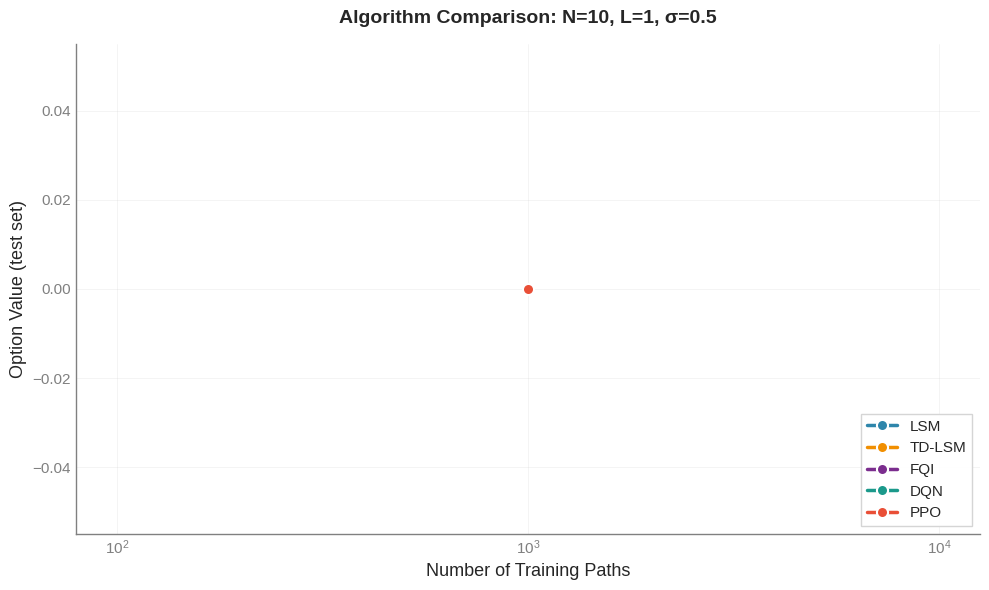

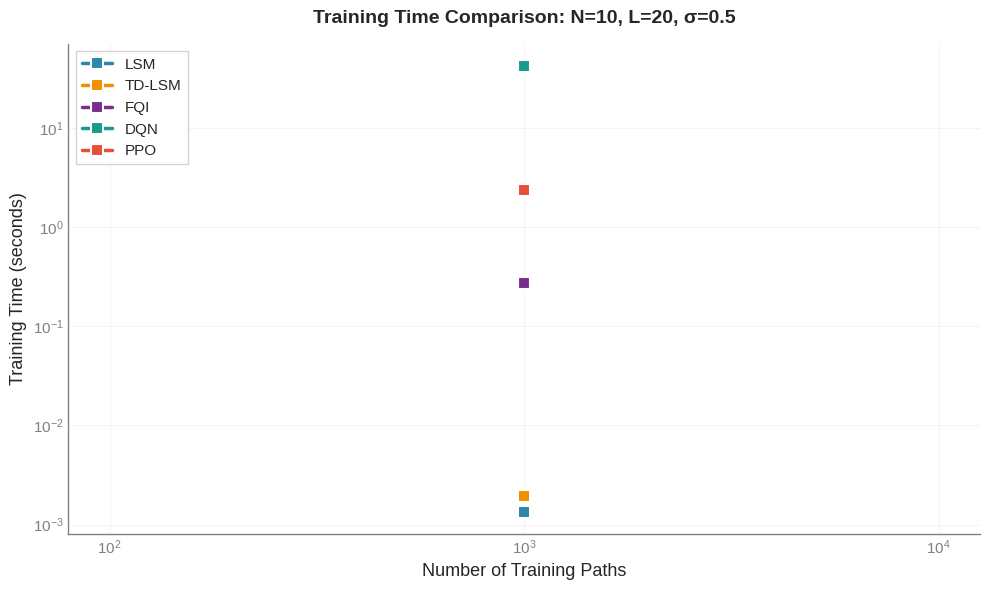


All configurations complete!


In [193]:
# ═══════════════════════════════════════════════════════════════════════════════
# Comparison: LSM vs TD-LSM vs DQN vs PPO vs FQI
# ═══════════════════════════════════════════════════════════════════════════════

# Define parameter configurations to test
param_configs = [
    {'N': 10 , 'L': 1, 'delta': 0, 'sigma': 0.5},   # Use smaller N for speed!
    # {'N': 100, 'L': 5, 'delta': 0, 'sigma': 0.5},
]

# SPEED SETTINGS - adjust these for faster runs
TEST_PATHS = 1      # Reduced from 10000 (5x speedup on evaluation)
# train_sizes = [20, 50, 100, 200]  # Fewer sizes
train_sizes = [1000]
n_repeats = 1      # Single run (no averaging) for speed

# Clean plot style
plt.style.use('seaborn-v0_8-whitegrid')

for config_idx, config in enumerate(param_configs):
    # Update params for this configuration
    test_params = Params(
        S0=params.S0, K=params.K, T=params.T, r=params.r,
        sigma=config.get('sigma', 0.5),
        N=config['N'], M=params.M, L=config['L'], 
        delta=config.get('delta', 0)
    )
    
    print(f"\n{'='*80}")
    print(f"Configuration {config_idx + 1}/{len(param_configs)}: N={test_params.N}, L={test_params.L}, delta={test_params.delta}, σ={test_params.sigma}")
    print(f"{'='*80}")
    
    # Generate test paths for this configuration
    test_paths_config = generate_paths(test_params, TEST_PATHS, seed=997)
    
    results = {algo: {'means': [], 'times': []} for algo in ['LSM', 'TD-LSM', 'FQI','DQN', 'PPO']}
    
    for n in train_sizes:
        algo_vals = {algo: [] for algo in results.keys()}
        algo_times = {algo: [] for algo in results.keys()}
    
        for rep in range(n_repeats):
            seed = 42 + rep
            paths_n = generate_paths(test_params, n, seed=seed)
            
            # Train each algorithm separately to track individual times
            t0 = time.time()
            m_lsm = train_lsm(paths_n, test_params)
            algo_times['LSM'].append(time.time() - t0)
            
            t0 = time.time()
            m_td = train_td_lsm(paths_n, test_params)
            algo_times['TD-LSM'].append(time.time() - t0)
            
            t0 = time.time()
            m_dqn = train_dqn(paths_n, test_params, n_epochs=5)
            algo_times['DQN'].append(time.time() - t0)
            
            t0 = time.time()
            m_ppo = train_ppo(paths_n, test_params, n_epochs=5)
            algo_times['PPO'].append(time.time() - t0)
            
            t0 = time.time()
            m_fqi = train_fqi(paths_n, test_params, n_iterations=3)
            algo_times['FQI'].append(time.time() - t0)
            
            # Evaluate all on same test set
            val_lsm, _ = evaluate_policy(m_lsm, test_paths_config, test_params)
            val_td, _ = evaluate_policy(m_td, test_paths_config, test_params)
            val_dqn, _ = evaluate_dqn(m_dqn, test_paths_config, test_params)
            val_ppo, _ = evaluate_ppo(m_ppo, test_paths_config, test_params)
            val_fqi, _ = evaluate_fqi(m_fqi, test_paths_config, test_params)
            
            algo_vals['LSM'].append(val_lsm)
            algo_vals['TD-LSM'].append(val_td)
            algo_vals['DQN'].append(val_dqn)
            algo_vals['PPO'].append(val_ppo)
            algo_vals['FQI'].append(val_fqi)
        
        # Store results
        for algo in results.keys():
            results[algo]['means'].append(np.mean(algo_vals[algo]))
            results[algo]['times'].append(np.mean(algo_times[algo]))
        
        total_time = sum(np.mean(algo_times[a]) for a in results.keys())
        print(f"n={n:>4d}  LSM={np.mean(algo_vals['LSM']):.4f}  "
              f"TD-LSM={np.mean(algo_vals['TD-LSM']):.4f}  "
              f"DQN={np.mean(algo_vals['DQN']):.4f}  "
              f"PPO={np.mean(algo_vals['PPO']):.4f}  "
              f"FQI={np.mean(algo_vals['FQI']):.4f}  "
              f"[total:{total_time:.1f}s]")
    
    # ── Clean Plot ──
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Professional color palette
    colors = {
        'LSM': '#2E86AB',      # Steel blue
        'TD-LSM': '#F18F01',
        'DQN': '#1B998B',      # Teal
        'PPO': '#E94F37',
        'FQI': '#7B2D8E'       # Purple
    }
    
    for algo in results.keys():
        means = np.array(results[algo]['means'])
        ax.plot(train_sizes, means, 
                marker='o', 
                color=colors[algo],
                label=algo, 
                linewidth=2.5, 
                markersize=8,
                markeredgecolor='white',
                markeredgewidth=1.5)
    
    ax.set_xlabel('Number of Training Paths', fontsize=13, fontweight='medium')
    ax.set_ylabel('Option Value (test set)', fontsize=13, fontweight='medium')
    ax.set_title(f'Algorithm Comparison: N={test_params.N}, L={test_params.L}, σ={test_params.sigma}', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xscale('log')
    
    # Clean legend
    ax.legend(fontsize=11, loc='lower right', frameon=True, 
              fancybox=False, edgecolor='lightgray', framealpha=0.95)
    
    # Refined grid
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('gray')
    ax.spines['bottom'].set_color('gray')
    ax.tick_params(colors='gray', labelsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # ── Training Time Plot ──
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    for algo in results.keys():
        times = np.array(results[algo]['times'])
        ax.plot(train_sizes, times, 
                marker='s', 
                color=colors[algo],
                label=algo, 
                linewidth=2.5, 
                markersize=8,
                markeredgecolor='white',
                markeredgewidth=1.5)
    
    ax.set_xlabel('Number of Training Paths', fontsize=13, fontweight='medium')
    ax.set_ylabel('Training Time (seconds)', fontsize=13, fontweight='medium')
    ax.set_title(f'Training Time Comparison: N={test_params.N}, L=20, σ={test_params.sigma}', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    ax.legend(fontsize=11, loc='upper left', frameon=True, 
              fancybox=False, edgecolor='lightgray', framealpha=0.95)
    
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('gray')
    ax.spines['bottom'].set_color('gray')
    ax.tick_params(colors='gray', labelsize=11)
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("All configurations complete!")
print("="*80)

### Visualaiser

In [194]:
import numpy as np
import scipy.stats as st

def compute_exact_boundaries(params, max_rights=1, n_grid=1500):
    """
    Solves the exact Bellman equation via backward induction on a discretized price grid.
    Returns: boundaries array of shape (max_rights + 1, N + 1)
    """
    # 1. Create a dense grid in log-price space
    log_S_min = np.log(params.K * 0.1)
    log_S_max = np.log(params.K * 5.0)
    log_S = np.linspace(log_S_min, log_S_max, n_grid)
    S = np.exp(log_S)
    
    payoff = np.maximum(params.K - S, 0)
    
    # 2. Precompute the exact GBM transition matrix
    mu_dt = (params.r - 0.5 * params.sigma**2) * params.dt
    std_dt = params.sigma * np.sqrt(params.dt)
    
    # P[i, j] is the probability of transitioning from log_S[i] to log_S[j]
    X, Y = np.meshgrid(log_S, log_S)
    P = st.norm.pdf(X, loc=Y + mu_dt, scale=std_dt)
    P = P / P.sum(axis=1, keepdims=True) # Normalize probabilities
    
    boundaries = np.zeros((max_rights + 1, params.N + 1))
    
    # V_prev_l holds the value function at each timestep for the previous right (l-1)
    V_prev_l = np.zeros((params.N + 1, n_grid))
    
    # 3. Backward Induction Loop
    for l in range(1, max_rights + 1):
        V_current = np.zeros((params.N + 1, n_grid))
        
        # At maturity (t=N)
        V_current[params.N] = payoff.copy()
        boundaries[l, params.N] = params.K
        
        for t in range(params.N - 1, 0, -1):
            # Continuation value (holding l rights)
            cont_val = np.exp(-params.r * params.dt) * (P @ V_current[t+1])
            
            # Exercise value (use 1 right, transition to l-1)
            if l == 1:
                ex_val = payoff
            else:
                # Immediate payoff + Expected discounted value of having l-1 rights at t+1
                # Note: Assuming delta=0 (no refractory period) as per your env setup
                ex_val = payoff + np.exp(-params.r * params.dt) * (P @ V_prev_l[t+1])
                
            # Optimal value at t
            V_current[t] = np.maximum(ex_val, cont_val)
            
            # The boundary is the highest price where exercise value >= continuation value
            exercise_mask = (ex_val >= cont_val - 1e-6) & (payoff > 0)
            if np.any(exercise_mask):
                boundaries[l, t] = S[np.where(exercise_mask)[0][-1]]
            else:
                boundaries[l, t] = 0.0 # No early exercise
                
        # Save this right's value function to compute the next right
        V_prev_l = V_current.copy()
        
    return boundaries

In [195]:
import numpy as np
import matplotlib.pyplot as plt
import torch

class OptionPolicyVisualizer:
    def __init__(self, params, device='cpu'):
        self.params = params
        self.device = device
        
        # Create a continuous price grid around the strike price (e.g., K +/- 50%)
        self.min_price = params.K * 0.1
        self.max_price = params.K * 1.5
        self.price_steps = 100  # Resolution of the y-axis
        self.prices = np.linspace(self.min_price, self.max_price, self.price_steps)
        self.times = np.arange(1, params.N + 1)
        
    def get_policy_grid(self, model, algo_name, rights_left=1, degree=3):
        """Evaluates the model over the Price x Time grid to find the decision boundary."""
        policy_grid = np.zeros((len(self.prices), len(self.times)))
        
        for t_idx, t in enumerate(self.times):
            for p_idx, price in enumerate(self.prices):
                
                # If OTM, forced hold
                pay = max(self.params.K - price, 0)
                if pay <= 0:
                    policy_grid[p_idx, t_idx] = 0
                    continue
                    
                # 1. LSM and TD-LSM Logic
                if algo_name in ['LSM', 'TD-LSM']:
                    if t == self.params.N:
                        policy_grid[p_idx, t_idx] = 1 if pay > 0 else 0
                        continue
                        
                    key = (rights_left, t)
                    if key in model:
                        x = poly_basis(np.array([[price]]), self.params.K, degree)[0]
                        cont_est = float(x @ model[key])
                        cont_est = np.clip(cont_est, 0.0, self.params.K)
                    else:
                        cont_est = 0.0
                        
                    t_resume = min(t + self.params.delta + 1, self.params.N)
                    future_val = query_V(model, np.array([price]), rights_left - 1, t_resume, self.params, degree)
                    ex_val = pay + (self.params.df ** (t_resume - t)) * future_val
                    
                    policy_grid[p_idx, t_idx] = 1 if ex_val > cont_est else 0

                # 2. DQN Logic
                elif algo_name == 'DQN':
                    state = make_state(np.array([price]), t, rights_left, self.params)
                    with torch.no_grad():
                        q_vals = model(torch.tensor(state, device=self.device))
                        action = q_vals.argmax().item()
                    policy_grid[p_idx, t_idx] = action

                # 3. PPO Logic
                elif algo_name == 'PPO':
                    state = make_state(np.array([price]), t, rights_left, self.params)
                    with torch.no_grad():
                        logits, _ = model(torch.tensor(state, device=self.device))
                        action = logits.argmax().item()
                    policy_grid[p_idx, t_idx] = action
                    
                # 4. FQI Logic
                elif algo_name == 'FQI':
                    state = make_state(np.array([price]), t, rights_left, self.params)
                    features = fqi_state_features(state, degree)
                    q0 = features @ model[0]
                    q1 = features @ model[1]
                    policy_grid[p_idx, t_idx] = 1 if q1 > q0 else 0
                    
        return policy_grid

    def compare_policies(self, models_dict, rights_left=1, degree=3):
        """Plots the learned boundaries of algorithms with the true mathematical boundary."""
        n_algos = len(models_dict)
        fig, axs = plt.subplots(1, n_algos, figsize=(5 * n_algos, 5.5), sharey=True)
        
        if n_algos == 1:
            axs = [axs]
            
        # --- NEW: Compute the exact mathematical boundary ---
        print("Computing exact mathematical boundary via DP...")
        exact_boundaries = compute_exact_boundaries(self.params, max_rights=rights_left)
        true_bnd = exact_boundaries[rights_left, 1:] # Drop t=0 index
        # ----------------------------------------------------

        for ax, (algo_name, model) in zip(axs, models_dict.items()):
            grid = self.get_policy_grid(model, algo_name, rights_left, degree)
            
            # Heatmap
            im = ax.imshow(grid, cmap='RdYlGn', vmin=0, vmax=1, 
                           aspect='auto', origin='lower',
                           extent=[1, self.params.N, self.min_price, self.max_price])
            
            # Strike Price Line
            ax.axhline(self.params.K, color='black', linestyle='--', linewidth=1.5, label='Strike Price (K)')
            
            # --- NEW: True Optimal Boundary Line ---
            valid_times = self.times[true_bnd > 0]
            valid_bnd = true_bnd[true_bnd > 0]
            ax.plot(valid_times, valid_bnd, color='blue', linewidth=2.5, linestyle='-', label='True Optimal Boundary')
            # ---------------------------------------

            # Formatting
            ax.set_title(f'{algo_name}', fontsize=14, fontweight='bold')
            ax.set_xlabel('Time Step (t)', fontsize=12)
            
            if ax == axs[-1]:
                ax.legend(loc='lower right', framealpha=0.95, fontsize=10)
                
        axs[0].set_ylabel('Asset Price', fontsize=12)
        fig.suptitle(f'Policy Comparison vs Ground Truth (Rights Left: {rights_left})\nGreen = Exercise, Red = Hold', 
                     fontsize=16, fontweight='bold', y=1.05)
        
        plt.tight_layout()
        plt.show()

Computing exact mathematical boundary via DP...


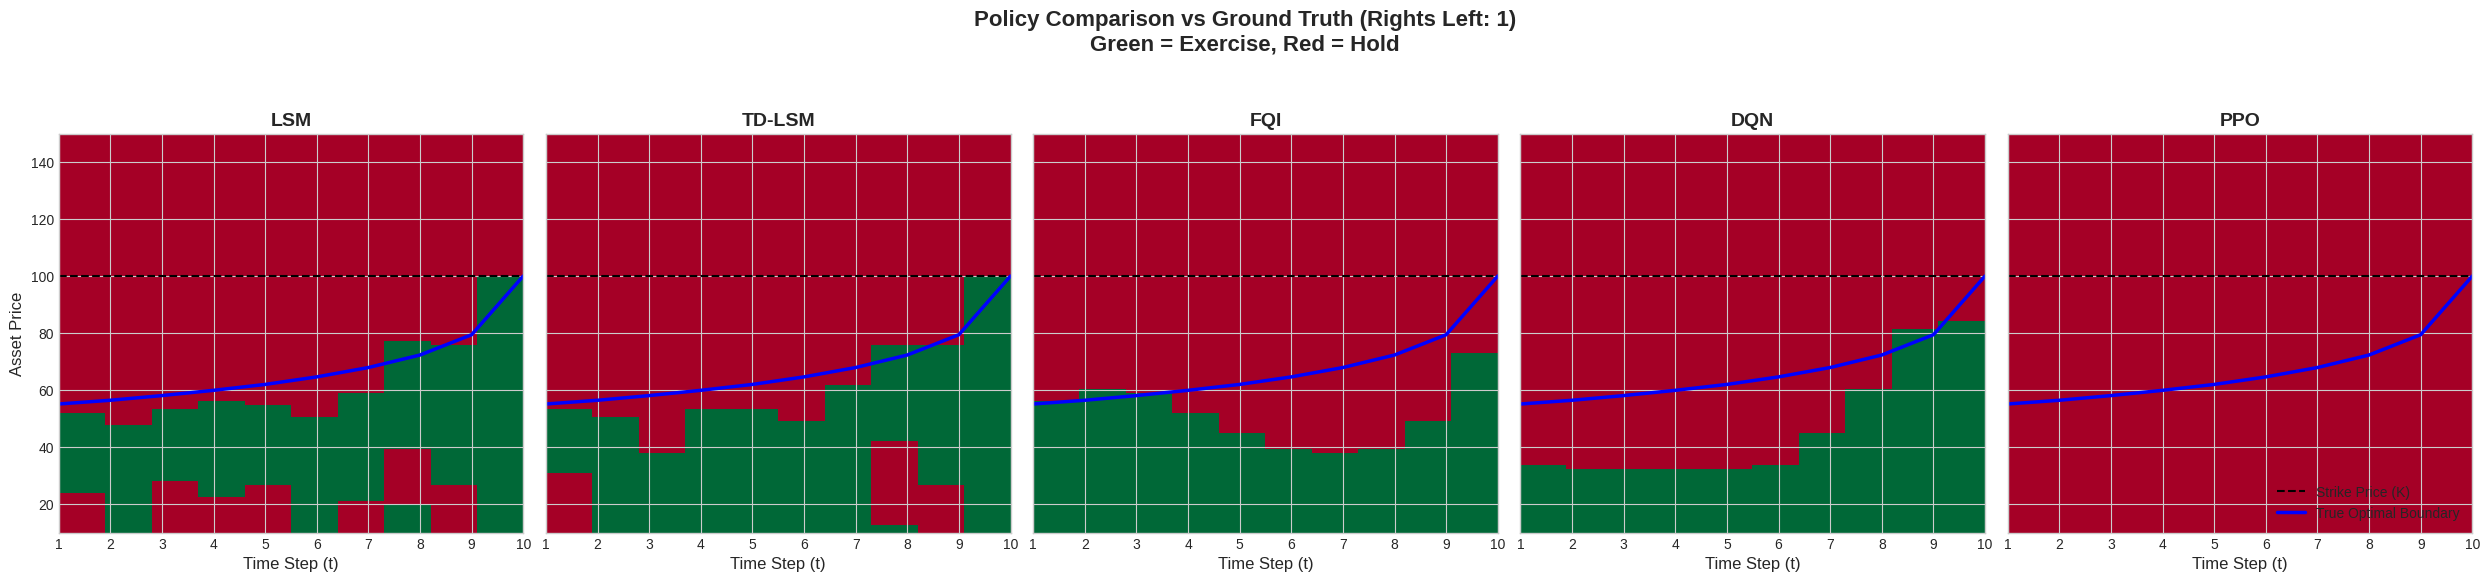

In [196]:
# 1. Gather your trained models into a dictionary
trained_models = {
    'LSM': m_lsm,
    'TD-LSM': m_td,
    'FQI': m_fqi,
    'DQN': m_dqn,
    'PPO': m_ppo
}

# 2. Instantiate the visualizer using the params from your last test run
viz = OptionPolicyVisualizer(test_params, device=device)

# 3. Compare the policies for the final remaining exercise right (L=1)
viz.compare_policies(trained_models, rights_left=1)

# You can also look at the policy when there are 2 rights left 
# viz.compare_policies(trained_models, rights_left=2)   